Your name: HU ZIHAO

Your matriculation number: G2401286D

Date: 11 Feb 2025


# FE8708 Programming Test

* Duration: **90 minutes**

* In each question, you are required to write some code **AND** to provide some verbal explanations (it can be clarifications on your codes, on the output of your codes, or answers to questions about machine learning models).

* The main part of the test is worth **90 out of 100**. In the main part, Python codes with some intentional mistakes are provided to you and you need to correct the mistakes rather than write a lot of code from scratch. There are also two bonus questions. You can get up to **10 out of 100** for solving them. Besides, you can get some bonus marks for writing clean reusable well-commented codes, for super-nice visualizations, for interesting ideas and particularly deep thoughts in your explanations.

* Mode: work individually. You may use materials from the course and Python manual. But you are not allowed to communicate with one another and you are not allowed to use generative AI tools, like ChatGPT.



* In the end, download your notebook as PYNB and submit to NTULearn.

## Preparation

This part is entirely prepared by Fedor and you shouldn't change anything here. Please run all the codes here first and read the instructions while waiting for all the data to be loaded into Python.

### Libaries

In [1]:
import time

import numpy as np
import pandas as pd
import plotly.express as px
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import matplotlib.pyplot as plt

import tensorflow as tf
import keras
from numpy.random import seed

from pprint import pprint

from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from keras import regularizers

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.datasets import fetch_20newsgroups
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

## GloVe

Now we will load the pre-trained word vectors into Python. Note that this will take some time. While word vectors are being loaded, please continue reading the handout.

In [2]:
### This is to download pre-trained word vectors.
### Takes about 3 minutes

!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip

### Comment it out after running once

--2025-02-11 10:44:31--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2025-02-11 10:44:31--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2025-02-11 10:44:31--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov


We will read 100-dimensional word embeddings from the file in two forms - python dictionary and pandas dataframe. You can use either form in this programming test.


In [18]:
path_to_glove_file = "glove.6B.100d.txt"

embeddings_index = {}
with open(path_to_glove_file) as f:
    for line in f:
        word, coefs = line.split(maxsplit=1)
        coefs = np.fromstring(coefs, "f", sep=" ") #to initialize a 1D array here
        embeddings_index[word] = coefs

print("Found %s word vectors." % len(embeddings_index))

df_glove = pd.DataFrame.from_dict(embeddings_index, orient='index', dtype=None)
print("dim(GloVe matrix) =", df_glove.shape)

print("Vector for 'buddha' is (first 5 entries):")
print(df_glove.loc['buddha', :][:5])
print("||v(buddha)|| =", np.linalg.norm(df_glove.loc['buddha', :]))
print("Alternatively, ||v(buddha)|| =", np.sqrt(np.sum(df_glove.loc['buddha', :] * df_glove.loc['buddha', :])))

Found 400000 word vectors.
dim(GloVe matrix) = (400000, 100)
Vector for 'buddha' is (first 5 entries):
0    0.48649
1    1.47960
2    0.15498
3    0.86981
4    0.50936
Name: buddha, dtype: float32
||v(buddha)|| = 6.1194615
Alternatively, ||v(buddha)|| = 6.1194615


### Data

We will work with a dataset of emails classified into 20 classes. The objectives are

* Visualize the data

* Apply unsupervised learning to get a feeling of what data look like

* Train a model for predicting the label.

Documents (emails) in the training set contain some metadata (like the sender's email) that may cause overfitting, so we remove the metadata.

We will also save the necessary information into several variables with meaningful names for convenience.

In [20]:
# Here we load the data:
newsgroups_train = fetch_20newsgroups(subset='train', remove = ('headers', 'footers', 'quotes'))
newsgroups_test = fetch_20newsgroups(subset='test', remove = ('headers', 'footers', 'quotes'))
# Note that the function 'fetch_20newsgroups' returns the data as a class of
# of some special type. For convenience, Fedor will save the necessary information
# into a data frame

class_labels = newsgroups_train.target_names # list of strings - class labels
y_train = newsgroups_train.target # response variable for the training set, numeric label
y_test = newsgroups_test.target   # response variable for the test set, numeric label

df_train = pd.DataFrame({'doc': newsgroups_train.data,
                         'y': newsgroups_train.target,
                         'label': np.array(class_labels)[y_train]})

df_test = pd.DataFrame({'doc': newsgroups_test.data,
                         'y': newsgroups_test.target,
                         'label': np.array(class_labels)[y_test]})

print("No of training examples:", df_train.shape[0])
print("No of test examples:", df_test.shape[0])

print("Labels and their frequencies in the training data:")
print(df_train.label.value_counts())
print("Sample of training data:")
df_train.head()

No of training examples: 11314
No of test examples: 7532
Labels and their frequencies in the training data:
label
rec.sport.hockey            600
soc.religion.christian      599
rec.motorcycles             598
rec.sport.baseball          597
sci.crypt                   595
rec.autos                   594
sci.med                     594
comp.windows.x              593
sci.space                   593
comp.os.ms-windows.misc     591
sci.electronics             591
comp.sys.ibm.pc.hardware    590
misc.forsale                585
comp.graphics               584
comp.sys.mac.hardware       578
talk.politics.mideast       564
talk.politics.guns          546
alt.atheism                 480
talk.politics.misc          465
talk.religion.misc          377
Name: count, dtype: int64
Sample of training data:


,doc,y,label
0,I was wondering if anyone out there could enli...,7,rec.autos
1,A fair number of brave souls who upgraded thei...,4,comp.sys.mac.hardware
2,"well folks, my mac plus finally gave up the gh...",4,comp.sys.mac.hardware
3,\nDo you have Weitek's address/phone number? ...,1,comp.graphics
4,"From article <C5owCB.n3p@world.std.com>, by to...",14,sci.space


Here is a quick look at a specific training example:

In [21]:
show_example = 10
print("Training example no", show_example, ":")
pprint(df_train.doc[show_example])
print("Its class:", df_train.y[show_example])
print("Its label:", df_train.label[show_example])

Training example no 10 :
('I have a line on a Ducati 900GTS 1978 model with 17k on the clock.  Runs\n'
 'very well, paint is the bronze/brown/orange faded out, leaks a bit of oil\n'
 'and pops out of 1st with hard accel.  The shop will fix trans and oil \n'
 'leak.  They sold the bike to the 1 and only owner.  They want $3495, and\n'
 'I am thinking more like $3K.  Any opinions out there?  Please email me.\n'
 "Thanks.  It would be a nice stable mate to the Beemer.  Then I'll get\n"
 'a jap bike and call myself Axis Motors!\n'
 '\n'
 '-- \n'
 '-----------------------------------------------------------------------\n'
 '"Tuba" (Irwin)      "I honk therefore I am"     CompuTrac-Richardson,Tx\n'
 'irwin@cmptrc.lonestar.org    DoD #0826          (R75/6)')
Its class: 8
Its label: rec.motorcycles


Now we will create a document-term matrix for the training data. We will only keep words that appear in at least 1% of the documents.

In [23]:
vec = CountVectorizer(min_df = 0.01)
DTM_train_mat = vec.fit_transform(df_train["doc"])
DTM_train_df = pd.DataFrame(DTM_train_mat.toarray(), columns=vec.get_feature_names_out())
print("dim(DTM) =", print(DTM_train_df.shape))
print("A sample of words that appear in the data:")
print(DTM_train_df.columns[np.arange(500, 520)])

(11314, 1380)
dim(DTM) = None
A sample of words that appear in the data:
Index(['format', 'former', 'forward', 'found', 'four', 'free', 'freedom',
       'friend', 'friends', 'from', 'front', 'ftp', 'full', 'fully', 'fun',
       'function', 'further', 'future', 'game', 'games'],
      dtype='object')


### Artificial neural networks

Here is a utility function for plotting training history of an articial neural network

In [76]:
def plot_train_history(hist):
    '''Converts information contained in hist to a data frame.
    And plots it as a line plot.'''
    train_history = pd.DataFrame(hist.history)
    col_names = train_history.columns
    train_history["epoch"] = np.arange(num_epochs) + 1
    fig = px.line(train_history, x = 'epoch', y = [col_names[0], col_names[2]])
    return fig

## Your work

Please insert your codes and your explanations below - they will be graded.

### Question 1 - word clouds

Plot two word clouds, one for all the documents labelled 'talk.politics.mideast' and one for all the documents labelled 'rec.autos'.

Based in these word clouds, answer the following questions:

1) Which Middle-Eastern country is mostly mentioned in discussions about Middle-East politics?

2) Is there a particular car brand that is commonly discussed in our dataset?

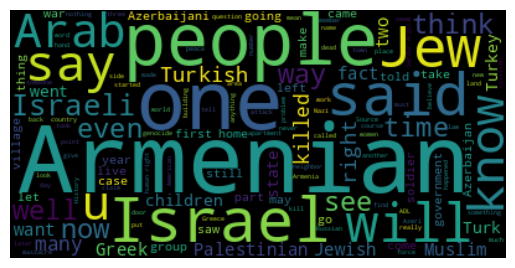

In [27]:
# This code procudes the word cloud for all the documents
# Modify it to plot two word clouds,
# one for label 'talk.politics.mideast'
# and one for label 'rec.autos'
# df_train = pd.DataFrame({'doc': newsgroups_train.data,
#                          'y': newsgroups_train.target,
#                          'label': np.array(class_labels)[y_train]})

# df_test = pd.DataFrame({'doc': newsgroups_test.data,
#                          'y': newsgroups_test.target,
#                          'label': np.array(class_labels)[y_test]})


# Filter the dataframe for the desired label
df_mideast_train = df_train[df_train['label'] == 'talk.politics.mideast']
df_mideast_test = df_test[df_test['label'] == 'talk.politics.mideast']
df_mideast = pd.concat([df_mideast_train, df_mideast_test])
# Join the documents into a single string
F_mideast = " ".join(df_mideast.doc)

# Generate the word cloud
wordcloud_mideast = WordCloud().generate(F_mideast)

# Display the word cloud
plt.imshow(wordcloud_mideast, interpolation='bilinear')
plt.axis("off")
plt.show()


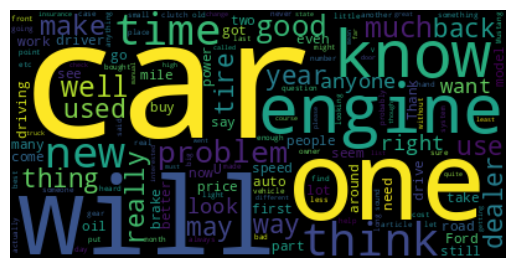

In [28]:
# This code procudes the word cloud for all the documents
# Modify it to plot two word clouds,
# one for label 'talk.politics.mideast'
# and one for label 'rec.autos'
# df_train = pd.DataFrame({'doc': newsgroups_train.data,
#                          'y': newsgroups_train.target,
#                          'label': np.array(class_labels)[y_train]})

# df_test = pd.DataFrame({'doc': newsgroups_test.data,
#                          'y': newsgroups_test.target,
#                          'label': np.array(class_labels)[y_test]})


# Filter the dataframe for the desired label
df_autos_train = df_train[df_train['label'] == 'rec.autos']
df_autos_test = df_test[df_test['label'] == 'rec.autos']
df_autos = pd.concat([df_autos_train, df_autos_test])
# Join the documents into a single string
F_mideast = " ".join(df_autos.doc)

# Generate the word cloud
wordcloud_mideast = WordCloud().generate(F_mideast)

# Display the word cloud
plt.imshow(wordcloud_mideast, interpolation='bilinear')
plt.axis("off")
plt.show()


_Answer:_

1) Which Middle-Eastern country is mostly mentioned in discussions about Middle-East politics?<br>


**According to first wordcloud, Armenia is mostly frequently discussed.**


2)Is there a particular car brand that is commonly discussed in our dataset?<br>

**Apparently,the answer is no.**




### Question 2 - feature generation

Feature generation. We will represent each document $D$ by the vector
$$
v(D)=
\frac{\sum_{w\in D}\mathrm{GloVe}(w)}{\left\|
\sum_{w\in D}\mathrm{GloVe}(w)
\right\|},
$$
where the sum is taken over all words $w$ in the document (only words whose frequency in the training set is at least 1% are included) and $\mathrm{GloVe}(w)$ is the pre-trained word embedding for word $w$ downloaded from Stanford University.

Generate the matrix features. To do it, you can correct the error in the Python code provided below.

Please also explain why we normalize the sums of word embeddings overs all words in the document, i.e., why we can't just define
$$
v(D)=
\sum_{w\in D}\mathrm{GloVe}(w)
$$

**Remark** Fedor tried to train a neural network with and without data normalization. It works slightly better with.


In [32]:
words_existing_in_text_and_glove = set(DTM_train_df.columns).intersection(set(df_glove.index))
print("Found ", len(words_existing_in_text_and_glove), "words in the news for which we have word vectors")

Found  1380 words in the news for which we have word vectors


Remarks: it seems that all words in news could be retrieved from glove.

_Answer_: <br>
**It is not difficult to realize that longer documents will naturally have a larger word embedding $v(D)$ (i.e. a larger value at the elements of the column vector) if we define the word embedding of a document using following way.
$$
v(D)=
\sum_{w\in D}\mathrm{GloVe}(w)
$$

Thus, there will be a bias towards the longer samples in training set during the training without the normalization of the word embeddings.**





In [35]:
# ## MODIFY THIS CODE:

# DTM_relevant = DTM_train_df[list(words_existing_in_text_and_glove)]

# DTM_train = DTM_train_df.iloc[:, :1000]
# glove_relevant = df_glove.iloc[:1000, :]
# print("dim(DTM =", DTM_train.shape)
# print("Sample of DTM:")
# print(DTM_train.iloc[:5, :5])
# print("\ndim(GloVe) =", glove_relevant.shape)
# print("Sample of GloVe:")
# print(glove_relevant.iloc[:5, :5])

# X_train = np.dot(DTM_train, glove_relevant)
# print("dim(X_train) =", X_train.shape)

# ## THE FOLLOWING IS A SANITY CHECK FOR YOU
# ## YOU DON'T NEED TO CHANGE IT
# print("\nSanity check: the following should be 0:")
# print(np.sum(DTM_train.columns != glove_relevant.index))


In [39]:
## MODIFY THIS CODE:

DTM_relevant = DTM_train_df[list(words_existing_in_text_and_glove)]
glove_relevant = df_glove.loc[list(words_existing_in_text_and_glove)]
print("dim(DTM =", DTM_relevant.shape)
print("Sample of DTM:")
print(DTM_relevant.iloc[:5, :5])
print("\ndim(GloVe) =", glove_relevant.shape)
print("Sample of GloVe:")
print(glove_relevant.iloc[:5, :5])

X_train = np.dot(DTM_relevant, glove_relevant)/np.linalg.norm(np.dot(DTM_relevant, glove_relevant))
print("dim(X_train) =", X_train.shape)

## THE FOLLOWING IS A SANITY CHECK FOR YOU
## YOU DON'T NEED TO CHANGE IT
print("\nSanity check: the following should be 0:")
print(np.sum(DTM_relevant.columns != glove_relevant.index))


dim(DTM = (11314, 1380)
Sample of DTM:
   completely  following  should  group  ask
0           0          0       0      0    0
1           0          0       0      0    0
2           0          0       0      0    0
3           0          0       0      0    0
4           0          0       0      0    0

dim(GloVe) = (1380, 100)
Sample of GloVe:
                   0         1        2         3         4
completely -0.429450 -0.062999  0.40084  0.384190  0.038682
following  -0.184480 -0.249580 -0.37156  0.002490 -0.110930
should     -0.044737  0.475150  0.26053 -0.392560 -0.293040
group       0.060976  0.386790 -0.25953 -0.450050  0.638190
ask        -0.168300 -0.001978  0.58425  0.049124 -0.714530
dim(X_train) = (11314, 100)

Sanity check: the following should be 0:
0


### Question 3 - PCA for visualization

Train a PCA model with 10 principal components for the data generated in Question 2, report the fraction of variance in the data explained by the principal components, and plot the dataset as a scatterplot on the axes (PC1, PC10).

Are principal components meaninful? Can we interpret them?

_Answer:_ <br>
**According to the plot of samples with pc1 and pc10 as axis, pc1 is definitely meaningful for classification of the news docuemnts while PC10 is not really helpful as the variance of PC10 is relatievely small.**





In [43]:

num_pc = 10
print("We will do PCA with", num_pc, "principal components")


### DO YOUR CHANGES HERE
X_old = X_train - np.mean(X_train,axis=0)
pca = PCA(n_components = num_pc)
pca.fit(X_old)
X_pc = pca.fit_transform(X_old)

### THE PART BELOW IS FINE

print("Fraction of variance explained by PCA:", np.round(np.sum(pca.explained_variance_ratio_), 3))
pca_df = pd.DataFrame(data = X_pc, columns = ['PC' + str(x+1) for x in range(num_pc)])
pca_df["label"] = df_train["label"]
pca_df.head()

We will do PCA with 10 principal components
Fraction of variance explained by PCA: 0.998


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,label
0,0.001328,-0.000015,-0.000023,0.000023,0.000101,0.000013,-0.000066,0.000075,0.000041,0.000044,rec.autos
1,0.001803,0.000122,0.000012,0.000054,0.000059,-0.000033,-0.000033,-0.000040,0.000046,-0.000063,comp.sys.mac.hardware
2,-0.002247,-0.000187,0.000063,0.000201,0.000100,-0.000131,-0.000082,0.000033,-0.000029,-0.000004,comp.sys.mac.hardware
3,0.002823,0.000037,0.000031,0.000029,0.000035,0.000023,0.000046,-0.000032,0.000011,-0.000010,comp.graphics
4,0.001862,0.000019,0.000059,0.000015,0.000024,-0.000009,0.000028,0.000023,-0.000014,0.000006,sci.space


Produce a scatterplot of the data with each point coloured according to the label

In [46]:
### DO YOUR CHANGES HERE
fig = px.scatter(pca_df, x = 'PC1', y = 'PC10', opacity = 0.1,color='label')
# fig.update_layout(xaxis_title='PC1', yaxis_title = "PC2")
fig.show()

### Question 4 - unsupervised learning

Based on the plot produced in Question 3, do you think that $K$-means clustering will produce visible meaningful clusters that are consistent with the labels?

Train a $K$-means clustering model with $K=20$ and print the contigency table showing frequencies of labels in each cluster to verify your answer to the question. Note that you are required to train $K$-means on the whole training set with GloVe-generated features, not on principal components.

_Answer:_ <br>
**K-means clusterning could not produce visible meaningful clusters that are consistent with the labels and this was indeed verified by the crosstable as shown below. Most of the samples falls in clusters 0,7,9 and 12 regardless of their labels. Most imoprtantly, the distribution of the labels inside all the clusters is relateively even. This suggests that K-means clustering did not yield meaningful outputs.**

In [48]:
K = 20
print("We are doing K-means clustering with K =", K)
kmeans = KMeans(K, random_state = 8128)           # Random state is chosen for reproducibility

### DO YOUR CHANGES HERE
kmeans.fit(X_old)
identified_clusters = kmeans.fit_predict(X_old)
### END OF CHANGES

#### CODES BELOW ARE FINE
pca_df["cluster"] = identified_clusters
pca_df["cluster"] = pca_df["cluster"].apply(str)  # This is to convert numeric labels to strings for plotting
print("Cluster frequencies:")
pca_df["cluster"].value_counts()

We are doing K-means clustering with K = 20
Cluster frequencies:


,count
cluster,
9,4761
0,3170
12,1697
7,826
4,395
18,221
11,100
2,57
6,26


In [49]:
# THIS PART IS FINE, DON'T CHANGE IT
pd.crosstab(pca_df["label"], pca_df["cluster"])

cluster,0,1,10,11,12,13,14,15,16,17,18,19,2,3,4,5,6,7,8,9
label,,,,,,,,,,,,,,,,,,,,
alt.atheism,137,0,0,4,80,0,2,0,1,0,13,0,3,1,21,0,0,39,0,179
comp.graphics,169,1,0,1,56,0,0,0,2,0,6,0,1,1,8,0,0,24,0,315
comp.os.ms-windows.misc,192,0,0,0,72,0,0,0,0,0,4,0,1,0,11,0,1,22,0,288
comp.sys.ibm.pc.hardware,221,0,0,1,76,0,1,1,0,0,4,0,1,0,6,0,0,39,0,240
comp.sys.mac.hardware,200,1,0,0,69,0,0,0,0,0,1,0,0,0,9,0,0,32,0,266
comp.windows.x,176,1,0,0,106,0,2,2,6,1,3,0,0,0,4,0,0,31,0,261
misc.forsale,163,0,0,1,47,0,0,0,0,0,1,0,0,0,7,0,0,25,0,341
rec.autos,160,0,0,2,95,0,1,0,0,0,4,0,2,0,10,0,0,28,0,292
rec.motorcycles,158,0,0,1,85,0,1,0,0,0,2,0,0,0,9,0,0,32,0,310


### Question 5 - predictive model

Train an artificual neural network for predicting the class label. Besides the input and the output layers, your model will have 3 fully-connected hidden layers with 256, 256, and 128 units respectively.

You need to change the code below (it contains several errors). Besides, note that we don't use our "official" test set here. Instead, we use a random split into training and validation sets on the go privided by `keras` package.

_Hint:_ you may want to explore the function `tf.keras.utils.to_categorical`.

Plot the history of training, i.e., training and validation accuracies as a function of epoch. Based on the history of training, do you conclude that your model overfits, underfits, or is just right? Depening on the answer to this question, how would you proceed in tuning the model if you had more time?

In [78]:
# This is for repdoducibility:
seed(42)
tf.random.set_seed(496)

#### DO YOUR CHANGES HERE:

model = Sequential()
model.add(Dense(256, input_dim = 100, activation='relu'))
model.add(Dense(256, activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dense(20, activation='softmax'))

print(model.summary())
model.compile(loss= keras.losses.CategoricalCrossentropy(), optimizer='adam', metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                     │ (None, 256)                 │          25,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 20)                  │           2,580 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 127,124 (496.58 KB)

 Trainable params: 127,124 (496.58 KB)

 Non-trainable params: 0 (0.00 B)

None


Below we actually train the model. Depending on changes you made in the previous code cell, you may need to introduce some changes here too.

In [82]:
num_epochs = 100
print("Training model for", num_epochs, "epochs")
start = time.time()

### DO YOUR CHANGES HERE:
y_train_cat = keras.utils.to_categorical(y_train, num_classes=len(set(y_train)))

history = model.fit(X_train, y_train_cat, validation_split = 0.2, \
                   verbose = 0, epochs=num_epochs, batch_size=256)


### END OF CHANGES


end = time.time()
print("Training the model took", np.round(end - start), "s")

# plot_train_history(history).show()


Training model for 100 epochs
Training the model took 52.0 s


In [83]:
plot_train_history(history).show()

In [81]:
pd.DataFrame(history.history)

,accuracy,loss,val_accuracy,val_loss
0,0.050050,2.993457,0.044631,2.995478
1,0.053585,2.989464,0.044631,2.994259
2,0.055132,2.984775,0.054795,2.987463
3,0.063087,2.972378,0.064958,2.978147
4,0.070489,2.962206,0.072912,2.969356
5,0.078665,2.956120,0.072912,2.962680
6,0.080433,2.951309,0.076005,2.958202
7,0.080102,2.947175,0.076889,2.953226
8,0.081317,2.943567,0.080424,2.948049
9,0.081206,2.939240,0.077331,2.943327


_Answer:_<br>
**Apparently,the model is underfitting as there is no sign of convergence of training accuracy. The train and validaiton accuracy is quite low. More epochs should be applied to train the ANN to yield the convergence. We would need to find a good combination of hyperparameters, such as weight decay. And we could experiment with different optimizers. process reasonably fast, we will need to create a small subset of the training set just for model tuning and we will pick a good combination of hyperparameters that doesn't lead to overfitting and yet yields a reasonable increase in accuracy over a few epochs.**



### Bonus Question 1

Note that we haven't evaluated our model on the official test set. Please do it. What is the test accuracy of our model? Please also provide verbal explanations of what makes the problem challenging and how you are going to solve it.

_Answer:_<br>

Test acc: 16.17%



In [84]:
### Write your code here

print("Here is our official test data:")
df_test.head()

Here is our official test data:


,doc,y,label
0,I am a little confused on all of the models of...,7,rec.autos
1,I'm not familiar at all with the format of the...,5,comp.windows.x
2,"\nIn a word, yes.\n",0,alt.atheism
3,\nThey were attacking the Iraqis to drive them...,17,talk.politics.mideast
4,\nI've just spent two solid months arguing tha...,19,talk.religion.misc


In [86]:
vec = CountVectorizer(min_df = 0.01)
DTM_test_mat = vec.fit_transform(df_test["doc"])
DTM_test_df = pd.DataFrame(DTM_test_mat.toarray(), columns=vec.get_feature_names_out())
print("dim(DTM) =", print(DTM_test_df.shape))
print("A sample of words that appear in the data:")
print(DTM_test_df.columns[np.arange(500, 520)])

words_existing_in_text_and_glove =set(DTM_test_df.columns).intersection(set(df_glove.index))

DTM_relevant = DTM_test_df[list(words_existing_in_text_and_glove)]
glove_relevant = df_glove.loc[list(words_existing_in_text_and_glove)]
print("dim(DTM =", DTM_relevant.shape)
print("Sample of DTM:")
print(DTM_relevant.iloc[:5, :5])
print("\ndim(GloVe) =", glove_relevant.shape)
print("Sample of GloVe:")
print(glove_relevant.iloc[:5, :5])

X_test = np.dot(DTM_relevant, glove_relevant)/np.linalg.norm(np.dot(DTM_relevant, glove_relevant))
print("dim(X_train) =", X_test.shape)



(7532, 1350)
dim(DTM) = None
A sample of words that appear in the data:
Index(['full', 'fully', 'fun', 'function', 'further', 'future', 'game',
       'games', 'gas', 'gave', 'general', 'generally', 'germany', 'get',
       'gets', 'getting', 'give', 'given', 'gives', 'giving'],
      dtype='object')
dim(DTM = (7532, 1350)
Sample of DTM:
   completely  following  should  group  ask
0           0          0       0      0    0
1           0          0       0      0    0
2           0          0       0      0    0
3           0          1       2      3    0
4           0          0       0      0    0

dim(GloVe) = (1350, 100)
Sample of GloVe:
                   0         1        2         3         4
completely -0.429450 -0.062999  0.40084  0.384190  0.038682
following  -0.184480 -0.249580 -0.37156  0.002490 -0.110930
should     -0.044737  0.475150  0.26053 -0.392560 -0.293040
group       0.060976  0.386790 -0.25953 -0.450050  0.638190
ask        -0.168300 -0.001978  0.58425  0.0491

In [88]:
y_test_cat = keras.utils.to_categorical(y_test, num_classes=len(set(y_test)))

model.evaluate(X_test,y_test_cat)

236/236 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1617 - loss: 2.5067


[2.491751194000244, 0.1631704717874527]

### Bonus Question 2

Train an LDA model on the training set and use its output as new features that you can add to the existing ones. In other words, create a new training and a new test set that have $100+k$ features, where $k$ is the number of topics in the LDA model. Does including features coming from LDA help to improve the accuracy of our model?

Please also provide verbal explanations of makes the problem challenging and how you are going to solve it.

_Answer:_



In [17]:
### Write your code here